I have a random sample of points: "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\randomsampleofpoints.shp"

They are based on the extent dissolved extent of these field boundaries: "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\LEMdataset.shp"

Some of the sampled points have more than 1 point per field in: "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\LEMdataset.shp"

I made hand annotations based on the random sampled points: "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\handlabeledexport.shp"

Created a column ID "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\LEMdataset.shp". 

I do spatial join so that the random points have the field ID. Remove all points after that have the same IDs so there is only 1 with each ID. 

I want to use this data to do find which fields most closely match between "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\handlabeledexport.shp" and  "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\LEMdataset.shp", only for those randomly sampled ones in the LEMdataset and compute metrics for intersection over union and other metrics that describe the agreement between two different polygons. 

I want each metric saved as a column in "D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\handlabeledexport.shp"  and also printed as an overall average value and histogram for each metric

C:\Users\grupp\AppData\Local\Temp\ipykernel_100436\3264034461.py:69: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  hand_labels_gdf.to_file(hand_labels_path, driver='ESRI Shapefile')
c:\Users\grupp\.virtualenvs\Field_Boundaries-U02EiQ07\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_ri_5'
  ogr_write(
c:\Users\grupp\.virtualenvs\Field_Boundaries-U02EiQ07\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Centroid_Distance' to 'Centroid_5'
  ogr_write(


Overall Average Metrics:
IoU                  0.696479
Dice                 0.765566
Jaccard              0.696479
Area_Diff            3.361925
Centroid_Distance    0.002445
dtype: float64


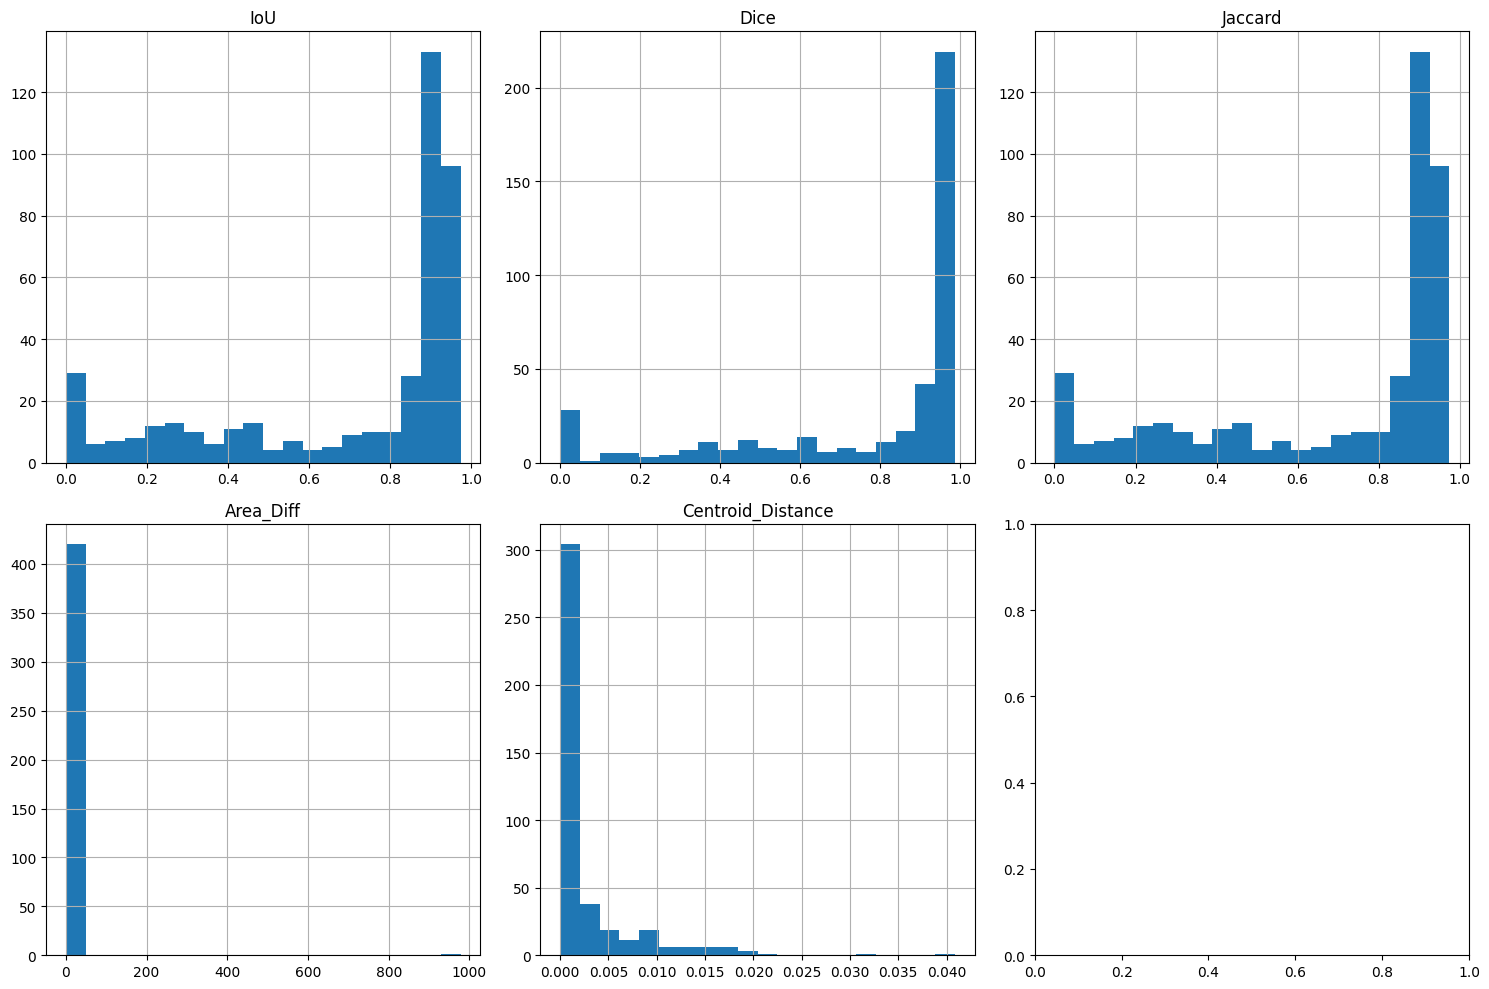

In [1]:
import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import os

# File paths
lem_dataset_path = r"D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\LEMdataset.shp"
random_points_path = r"D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\randomsampleofpoints.shp"
hand_labels_path = r"D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\handlabeledexport.shp"

# Load datasets
lem_gdf = gpd.read_file(lem_dataset_path)
random_points_gdf = gpd.read_file(random_points_path)
hand_labels_gdf = gpd.read_file(hand_labels_path)

# Step 1: Ensure LEM dataset has a unique ID column
if 'Field_ID' not in lem_gdf.columns:
    lem_gdf['Field_ID'] = range(1, len(lem_gdf) + 1)
else:
    lem_gdf = lem_gdf[['Field_ID', 'geometry']].copy()

# Step 2: Clean previous runs' artifacts from random points dataset
random_points_gdf = random_points_gdf[[col for col in random_points_gdf.columns if not col.endswith('_left') and not col.endswith('_right')]]
random_points_gdf = random_points_gdf.drop(columns=['Field_ID'], errors='ignore')

# Spatial Join - Assign Field IDs to random points
random_points_gdf = gpd.sjoin(random_points_gdf, lem_gdf, how='left', predicate='intersects')
random_points_gdf = random_points_gdf.drop_duplicates(subset=['Field_ID']).reset_index(drop=True)

# Step 3: Clean previous runs' artifacts from hand-labeled dataset
hand_labels_gdf = hand_labels_gdf[[col for col in hand_labels_gdf.columns if not col.endswith('_left') and not col.endswith('_right')]]
hand_labels_gdf = hand_labels_gdf.drop(columns=['Field_ID', 'IoU', 'Dice', 'Jaccard', 'Area_Diff', 'Centroid_Distance'], errors='ignore')

# Spatial Join - Assign Field IDs to hand-labeled data
hand_labels_gdf = gpd.sjoin(hand_labels_gdf, lem_gdf, how='left', predicate='intersects')
hand_labels_gdf = hand_labels_gdf.reset_index(drop=True)

# Step 4: Compute Metrics for Agreement
def compute_metrics(row, lem_gdf):
    field_id = row['Field_ID']
    
    if pd.isna(field_id) or field_id not in lem_gdf['Field_ID'].values:
        return pd.Series([None, None, None, None, None], 
                         index=['IoU', 'Dice', 'Jaccard', 'Area_Diff', 'Centroid_Distance'])
    
    lem_poly = lem_gdf.loc[lem_gdf['Field_ID'] == field_id, 'geometry'].iloc[0]
    hand_poly = row.geometry
    
    intersection = lem_poly.intersection(hand_poly).area
    union = lem_poly.union(hand_poly).area
    iou = intersection / union if union > 0 else None
    
    dice = (2 * intersection) / (lem_poly.area + hand_poly.area) if (lem_poly.area + hand_poly.area) > 0 else None
    jaccard = iou
    area_diff = abs(hand_poly.area - lem_poly.area) / lem_poly.area if lem_poly.area > 0 else None
    centroid_distance = lem_poly.centroid.distance(hand_poly.centroid)
    
    return pd.Series([iou, dice, jaccard, area_diff, centroid_distance], 
                     index=['IoU', 'Dice', 'Jaccard', 'Area_Diff', 'Centroid_Distance'])

# Apply function to hand-labeled dataset
hand_labels_gdf[['IoU', 'Dice', 'Jaccard', 'Area_Diff', 'Centroid_Distance']] = hand_labels_gdf.apply(lambda row: compute_metrics(row, lem_gdf), axis=1)

# Save updated hand-labeled dataset, overwriting previous file
if os.path.exists(hand_labels_path):
    os.remove(hand_labels_path)
hand_labels_gdf.to_file(hand_labels_path, driver='ESRI Shapefile')

# Step 5: Compute overall averages and visualize
average_metrics = hand_labels_gdf[['IoU', 'Dice', 'Jaccard', 'Area_Diff', 'Centroid_Distance']].mean()
print("Overall Average Metrics:")
print(average_metrics)

# Plot histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['IoU', 'Dice', 'Jaccard', 'Area_Diff', 'Centroid_Distance']
for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    hand_labels_gdf[metric].dropna().hist(ax=ax, bins=20)
    ax.set_title(metric)
plt.tight_layout()
plt.show()



create four groups (quartiles based on Field_Size)

and find the average value of the columns IoU, Dice, and Centroid_D for each, printing them as a table.

1st quartile and the 4th of Field_Size and plot a histogram for those two categories of size, with a separate histogram for each of the three metrics

C:\Users\grupp\AppData\Local\Temp\ipykernel_100436\3353335251.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_ranges = hand_labels_gdf.groupby('Size_Quartile')['Field_Size'].agg(['min', 'max'])
C:\Users\grupp\AppData\Local\Temp\ipykernel_100436\3353335251.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_summary = hand_labels_gdf.groupby('Size_Quartile')[['IoU', 'Dice', 'Centroid_D']].mean()


Field_Size Quartile Ranges (Min-Max):
                      min         max
Size_Quartile                        
Q1               1.596130  116.267639
Q2             116.753612  197.511586
Q3             197.812515  265.735941
Q4             266.318794  956.755984

Average Values by Field Size Quartile:
                    IoU      Dice  Centroid_D
Size_Quartile                                
Q1             0.680955  0.764116    0.001706
Q2             0.752886  0.811546    0.001913
Q3             0.726143  0.785676    0.002329
Q4             0.626078  0.700940    0.005652


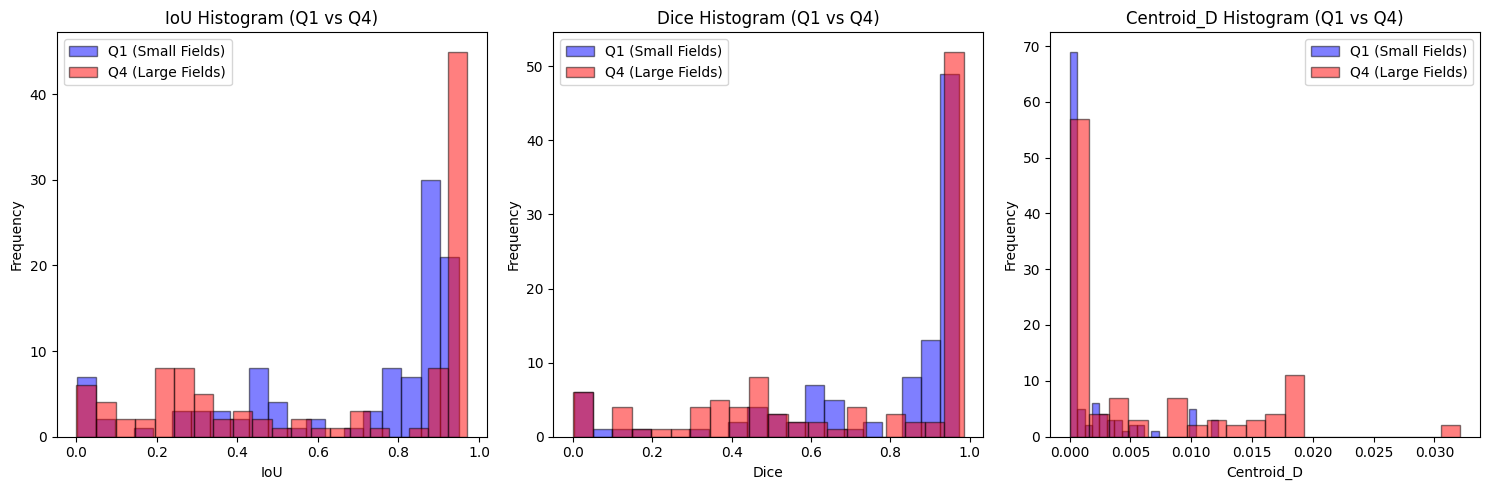

In [5]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# File path
hand_labels_path = r"D:\WRI\Field Boundaries\Bahia Brazil Hand Annotation Validation\FInal\handlabeledexport.shp"

# Load dataset
hand_labels_gdf = gpd.read_file(hand_labels_path)

# Ensure numeric values
hand_labels_gdf[['Field_Size', 'IoU', 'Dice', 'Centroid_D']] = hand_labels_gdf[['Field_Size', 'IoU', 'Dice', 'Centroid_D']].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values in required columns
hand_labels_gdf = hand_labels_gdf.dropna(subset=['Field_Size', 'IoU', 'Dice', 'Centroid_D'])

# Create quartile groups based on Field_Size
hand_labels_gdf['Size_Quartile'] = pd.qcut(hand_labels_gdf['Field_Size'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Compute the min and max range for each quartile
quartile_ranges = hand_labels_gdf.groupby('Size_Quartile')['Field_Size'].agg(['min', 'max'])

# Compute average IoU, Dice, and Centroid_D for each quartile
quartile_summary = hand_labels_gdf.groupby('Size_Quartile')[['IoU', 'Dice', 'Centroid_D']].mean()

# Print the quartile ranges
print("Field_Size Quartile Ranges (Min-Max):")
print(quartile_ranges)

# Print the summary table
print("\nAverage Values by Field Size Quartile:")
print(quartile_summary)

# Extract 1st and 4th quartile data
q1_data = hand_labels_gdf[hand_labels_gdf['Size_Quartile'] == 'Q1']
q4_data = hand_labels_gdf[hand_labels_gdf['Size_Quartile'] == 'Q4']

# Plot overlaid histograms for IoU, Dice, and Centroid_D
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['IoU', 'Dice', 'Centroid_D']
colors = {'Q1': 'blue', 'Q4': 'red'}

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Plot Q1
    ax.hist(q1_data[metric], bins=20, alpha=0.5, color=colors['Q1'], edgecolor='black', label='Q1 (Small Fields)')
    
    # Plot Q4
    ax.hist(q4_data[metric], bins=20, alpha=0.5, color=colors['Q4'], edgecolor='black', label='Q4 (Large Fields)')
    
    ax.set_title(f'{metric} Histogram (Q1 vs Q4)')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()
